# Validate U-DEM

This script validates U-DEM - both against the ArcticDEM strips, but also against ICESat-2 elevations

In [1]:
import xarray as xr
import validation_tools as vtools 
import matplotlib.pyplot as plt 
import numpy as np
import rioxarray
import os
import geopandas
import pandas as pd
import matplotlib.colors as mcolors
import string
from matplotlib.cm import ScalarMappable
import matplotlib as mpl
from matplotlib.colors import Normalize

# Validation with respect to ICESat-2

In [2]:

experiment = "v1-0"

projectDir = "/Users/rfk471/Dropbox/elevation-canada"

project_crs = "EPSG:3413"


# Region ids for the entire domain
region_ids_full = ["01","02","03","04","05","06","07","08","09","10","11","12","13","14","15"]

# Region ids for the regions to be used in training and validating the model 
# These regions also contain ArcticDEM data
region_ids_model = ["01","02","03","04","05","06","12","15"]

# Region ids which are only predicted on (no ArcticDEM data for these regions)
region_ids_prediction = [x for x in region_ids_full if x not in region_ids_model] + [x for x in region_ids_model if x not in region_ids_full]



In [4]:

udem_all, is2_all, cs_all = np.array([]), np.array([]), np.array([])


for region_id in region_ids_full:
    udem = xr.load_dataset(f"{projectDir}/data/final/udem_region-{region_id}_{experiment}_all.nc")["udem"]
    is2 = xr.load_dataset(f"{projectDir}/data/initial/icesat-2/icesat-2_grid_region-{region_id}.nc")["h"]
    cs = xr.load_dataset(f"{projectDir}/data/interim/region-{region_id}/cryoswath_seasonal/cs_raw_gathered_region-{region_id}.nc")["cs-elevation"]

    arcticdem_path = f"{projectDir}/data/initial/ArcticDEM/region-{region_id}/arcticdem_mosaic_100m_v4.1_dem_region-{region_id}.tif"
    mosaic = rioxarray.open_rasterio(arcticdem_path, masked=True).squeeze()
    is2_diff = is2 - mosaic
    is2_filtered = is2.where(np.abs(is2_diff) <= 100)


    udem_arr1, is2_arr1 = vtools.common_array(udem,is2_filtered)

    udem_arr, is2_arr, cs_arr = vtools.common_array_three(udem,is2_filtered,cs)

    udem_all = np.concat([udem_all,udem_arr],axis=None)
    is2_all = np.concat([is2_all,is2_arr],axis=None)
    cs_all = np.concat([cs_all,cs_arr],axis=None)


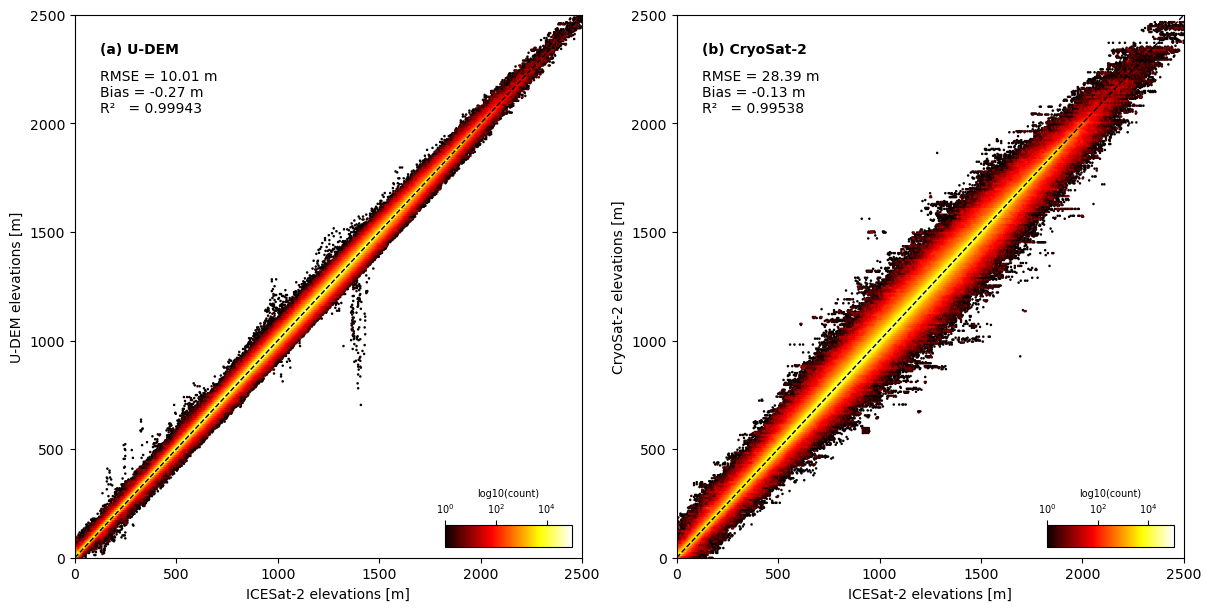

In [5]:
vtools.plot_icesat2_validation_overall(udem_all,cs_all,is2_all,projectDir,experiment)

Processing region 01
Processing region 02
Processing region 03
Processing region 04
Processing region 05
Processing region 06
Processing region 07
Processing region 08
Processing region 09
Processing region 10
Processing region 11
Processing region 12
Processing region 13
Processing region 14
Processing region 15


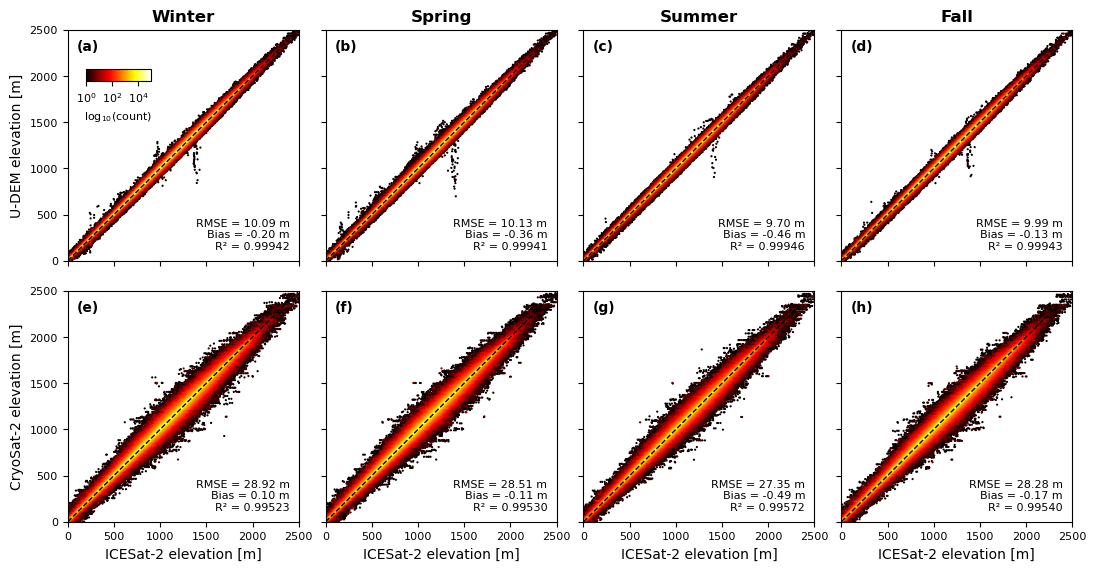

In [7]:
vtools.plot_seasonal_icesat2_validation(region_ids_full,projectDir,experiment)

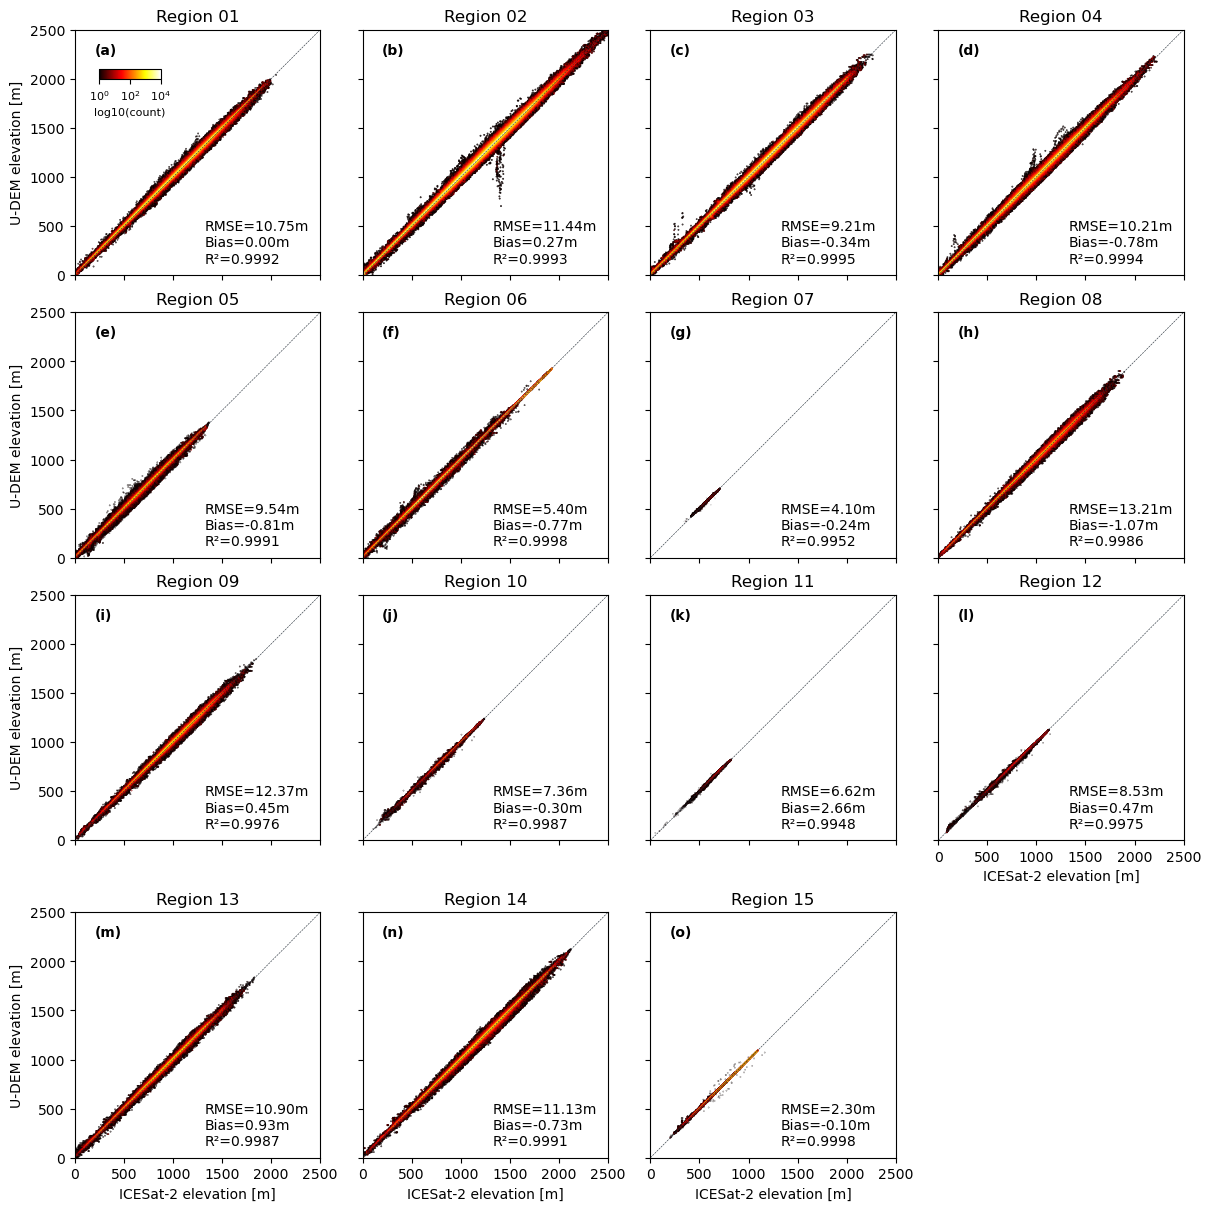

In [3]:
vtools.plot_regional_icesat2_validation("U-DEM",region_ids_full,projectDir,experiment)

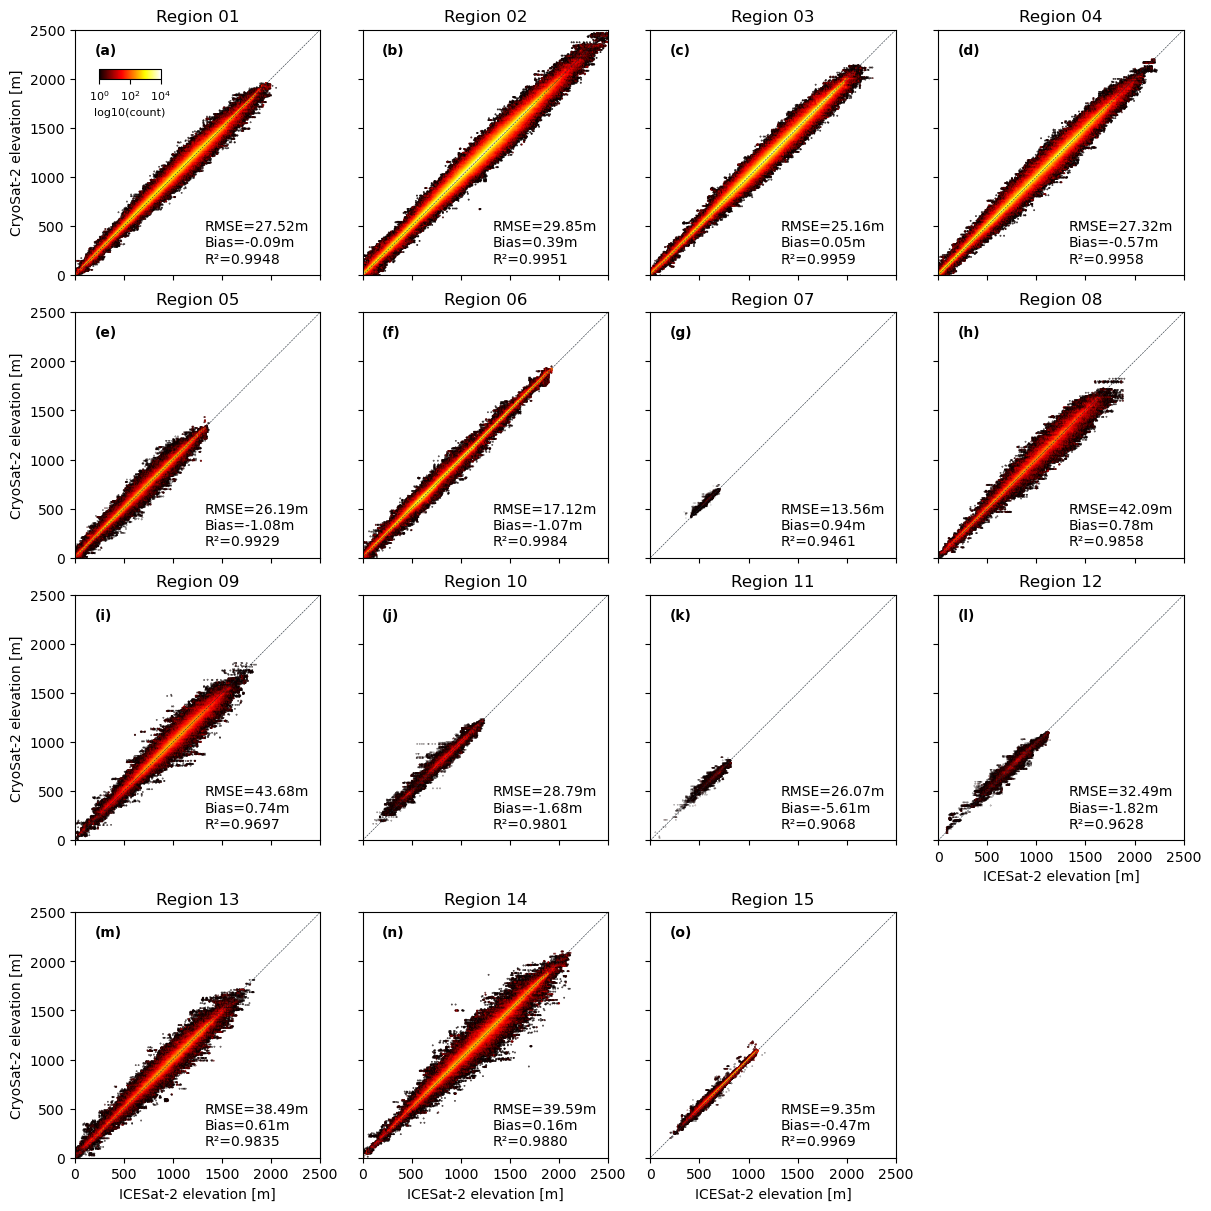

In [4]:
vtools.plot_regional_icesat2_validation("CryoSat-2",region_ids_full,projectDir,experiment)

Processing region 01
Processing region 02
Processing region 03
Processing region 04
Processing region 05
Processing region 06
Processing region 07
Processing region 08
Processing region 09
Processing region 10
Processing region 11
Processing region 12
Processing region 13
Processing region 14
Processing region 15


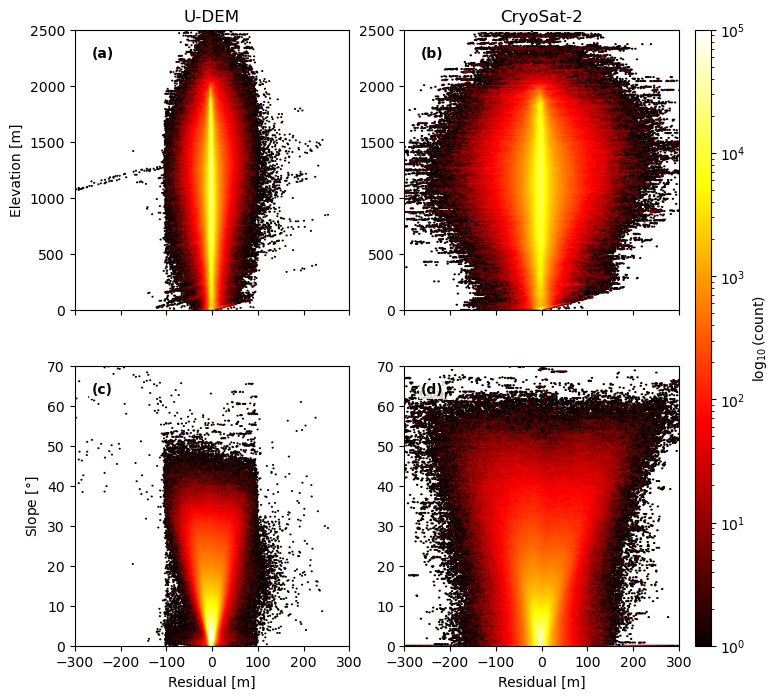

In [8]:
vtools.plot_slope_elevation_validation(region_ids_full,projectDir,experiment,project_crs)

In [22]:
# region_id = "01"

# udem = xr.load_dataset(f"{projectDir}/data/final/udem_region-{region_id}_{experiment}_all.nc")["udem"]
# adem = xr.load_dataset(f"{projectDir}/data/interim/region-{region_id}/ArcticDEM/ArcticDEM_raw_gathered_region-{region_id}.nc")["adem-elevation"]
# cs = xr.load_dataset(f"{projectDir}/data/interim/region-{region_id}/cryoswath_seasonal/cs_raw_gathered_region-{region_id}.nc")["cs-elevation"]
# s1 = xr.load_dataset(f"{projectDir}/data/interim/region-{region_id}/sentinel-1/S1_gathered_region-{region_id}.nc")["s1-backscatter"]


# rgi = geopandas.read_file(f"{projectDir}/data/initial/RGI/RGI2000-v7.0-C-03_arctic_canada_north/RGI2000-v7.0-C-03_arctic_canada_north.shp").to_crs(project_crs)
# xmin, xmax = -8.1e5, -7.9e5
# ymin, ymax = -8.e5, -7.8e5

# emin,emax = 600,1600
# smin, smax = -15, 15

# #labels = ["U-DEM", "ArcticDEM", "CryoSat-2", "Sentinel-1"]

# ctime = udem.time[14]
# #title = "Spring 2018"


In [23]:
# import matplotlib.colors as mcolors

# colors_bar = ["#FCE5D0","#F4A261","#F28C28","#C56A1A","#D9EAF7","#328CC1","#0B3C5D","#1D2731"]


# colors_elev = [
#     "#FCE5D0",  # very low
#     "#F4A261",
#     "#F28C28",
#     "#C56A1A",  # mid elevations
#     "#D9EAF7",  # start of high elevations
#     "#328CC1",
#     "#0B3C5D",
#     "#1D2731"   # highest elevations
# ]

# colors_elev = [
#     "#FCE5D0",  # very low
#     "#F4A261",
#     "#F28C28",
#     "#C56A1A",  # mid elevations
#     "#0B3C5D",
#     "#1D2731"   # highest elevations
# ]

# # Create the colormap
# elev_cmap = mcolors.LinearSegmentedColormap.from_list("elevation_theme", colors_elev, N=256)

# colors_bs = [
#     "#C56A1A",  # mid elevations
#     "#F28C28",
#     "#F4A261",
#     "#FCE5D0",
#     "#D9EAF7",  # start of high elevations
#     "#328CC1",
#     "#0B3C5D",
#     "#1D2731"   # highest elevations
# ]

# colors_bs = [
#     "#D9EAF7",  # start of high elevations
#     "#328CC1",
#     "#0B3C5D",
#     "#1D2731"   # highest elevations
# ]

# # Create the colormap
# bs_cmap = mcolors.LinearSegmentedColormap.from_list("bs_theme", colors_bs, N=256)

In [24]:
# text_color = "#1D2731"
# with plt.rc_context({
#     'font.family': 'DejaVu Sans Mono',
#     'text.color': text_color,
#     'axes.labelcolor': text_color,
#     'axes.edgecolor': text_color,
#     'xtick.color': text_color,
#     'ytick.color': text_color,
#     'axes.titlecolor': text_color,
#     'legend.edgecolor': text_color
# }):

#     fig,ax = plt.subplots(figsize=(7,5))

#     udem.sel(time=ctime).plot(ax=ax,vmin=emin,vmax=emax,cmap="gist_earth",cbar_kwargs={'label': 'Elevation [m]'})
#     ax.plot([-794000,-791000],[-782500,-782500],linewidth=3,color=text_color)
#     ax.annotate("3 km", (-793500,-782000), xycoords='data',color=text_color)
#     ax.set_xlim(xmin,xmax)
#     ax.set_ylim(ymin,ymax)
#     ax.set_aspect("equal")
#     ax.set_title(' ')
#     ax.set_xticks([])
#     ax.set_yticks([])
#     ax.set_xlabel(' ')
#     ax.set_ylabel(' ')

#     fig.savefig(f"{projectDir}/figures/EGUposter_udem_{experiment}.png",dpi=600)

In [25]:
# text_color = "#1D2731"
# with plt.rc_context({
#     'font.family': 'DejaVu Sans Mono',
#     'text.color': text_color,
#     'axes.labelcolor': text_color,
#     'axes.edgecolor': text_color,
#     'xtick.color': text_color,
#     'ytick.color': text_color,
#     'axes.titlecolor': text_color,
#     'legend.edgecolor': text_color
# }):

#     fig,ax = plt.subplots(figsize=(7,5))

#     cs.sel(time=ctime).plot(ax=ax,vmin=emin,vmax=emax,cmap="gist_earth",cbar_kwargs={'label': 'Elevation [m]'})
#     ax.plot([-794000,-791000],[-782500,-782500],linewidth=3,color=text_color)
#     ax.annotate("3 km", (-793500,-782000), xycoords='data',color=text_color)
#     ax.set_xlim(xmin,xmax)
#     ax.set_ylim(ymin,ymax)
#     ax.set_aspect("equal")
#     ax.set_title(' ')
#     ax.set_xticks([])
#     ax.set_yticks([])
#     ax.set_xlabel(' ')
#     ax.set_ylabel(' ')
#     fig.savefig(f"{projectDir}/figures/EGUposter_cs_{experiment}.png",dpi=600)

In [26]:
# text_color = "#1D2731"
# with plt.rc_context({
#     'font.family': 'DejaVu Sans Mono',
#     'text.color': text_color,
#     'axes.labelcolor': text_color,
#     'axes.edgecolor': text_color,
#     'xtick.color': text_color,
#     'ytick.color': text_color,
#     'axes.titlecolor': text_color,
#     'legend.edgecolor': text_color
# }):

#     fig,ax = plt.subplots(figsize=(7,5))

#     adem.sel(time=ctime).plot(ax=ax,vmin=emin,vmax=emax,cmap="gist_earth",cbar_kwargs={'label': 'Elevation [m]'})
#     ax.plot([-794000,-791000],[-782500,-782500],linewidth=3,color=text_color)
#     ax.annotate("3 km", (-793500,-782000), xycoords='data',color=text_color)
#     ax.set_xlim(xmin,xmax)
#     ax.set_ylim(ymin,ymax)
#     ax.set_aspect("equal")
#     ax.set_title(' ')
#     ax.set_xticks([])
#     ax.set_yticks([])
#     ax.set_xlabel(' ')
#     ax.set_ylabel(' ')
#     fig.savefig(f"{projectDir}/figures/EGUposter_adem_{experiment}.png",dpi=600)

In [27]:
# text_color = "#1D2731"
# with plt.rc_context({
#     'font.family': 'DejaVu Sans Mono',
#     'text.color': text_color,
#     'axes.labelcolor': text_color,
#     'axes.edgecolor': text_color,
#     'xtick.color': text_color,
#     'ytick.color': text_color,
#     'axes.titlecolor': text_color,
#     'legend.edgecolor': text_color
# }):

#     fig,ax = plt.subplots(figsize=(7,5))

#     s1.sel(time=ctime).plot(ax=ax,vmin=-15,vmax=10,cmap=bs_cmap,cbar_kwargs={'label': 'Backscatter [dB]'})
#     ax.plot([-794000,-791000],[-782500,-782500],linewidth=3,color="#FCE5D0")
#     ax.annotate("3 km", (-793500,-782000), xycoords='data',color="#FCE5D0")
#     ax.set_xlim(xmin,xmax)
#     ax.set_ylim(ymin,ymax)
#     ax.set_aspect("equal")
#     ax.set_title(' ')
#     ax.set_xticks([])
#     ax.set_yticks([])
#     ax.set_xlabel(' ')
#     ax.set_ylabel(' ')
#     fig.savefig(f"{projectDir}/figures/EGUposter_s1_{experiment}.png",dpi=600)

# Validation with respect to GPS measurements on White Glacier

In [29]:
region_id = "01"

In [30]:
def to_geopandas(data):

    # Convert DMS to decimal degrees
    def dms_to_dd(degrees, minutes, seconds):
        sign = -1 if degrees < 0 else 1
        return sign * (abs(degrees) + minutes / 60 + seconds / 3600)

    # Create decimal latitude and longitude
    data["latitude"] = data.apply(
        lambda row: dms_to_dd(row["LATDD"], row["LATMN"], row["LATSS"]),
        axis=1
    )

    data["longitude"] = data.apply(
        lambda row: dms_to_dd(row["LONDD"], row["LONMN"], row["LONSS"]),
        axis=1
    )

    # Create geometry column
    geometry = geopandas.points_from_xy(data["longitude"],data["latitude"])

    # Create GeoDataFrame
    gdf = geopandas.GeoDataFrame(data,geometry=geometry,crs="EPSG:4326")
    return gdf

In [31]:
antenna_height = pd.DataFrame({ "year": [2014,2015,2017,2018,2019,2023,2024],
                                "height": [1.,1.,1.,1.32,0.975,0.9,0.94],
                                "height_unc":[.25, .25, .25, .01, .01, .01, .01]})


columns=[
    "YEAR-MM-DD",
    "HR:MN:SS.SS",
    "LATDD",
    "LATMN",
    "LATSS",
    "LONDD",
    "LONMN",
    "LONSS",
    "HGT(m)",
    "SDHGT(95%)"
]

data_dir = f"{projectDir}/data/initial/in-situ"

In [32]:
mask_dir = f"{projectDir}/data/interim/region-{region_id}/masks/"
mask = rioxarray.open_rasterio(os.path.join(mask_dir,'mask_100m.tif')).squeeze()

udem = xr.load_dataset(f"{projectDir}/data/final/udem_region-{region_id}_{experiment}_all.nc")["udem"]
udem_masked = udem.where(mask==1)
udem_masked = udem_masked.rio.write_crs(project_crs)

cs = xr.load_dataset(f"{projectDir}/data/interim/region-{region_id}/cryoswath_seasonal/cs_raw_gathered_region-{region_id}.nc")["cs-elevation"]
cs_masked = cs.where(mask==1)
cs_masked = cs_masked.rio.write_crs(project_crs)

adem = xr.load_dataset(f"{projectDir}/data/interim/region-{region_id}/ArcticDEM/ArcticDEM_raw_gathered_region-{region_id}.nc")["adem-elevation"]
adem_masked = adem.where(mask==1)
adem_masked = adem_masked.rio.write_crs(project_crs)

dataDir = f"{projectDir}/data/initial/RGI"
RGI_n = geopandas.read_file(dataDir+"/RGI2000-v7.0-G-03_arctic_canada_north/RGI2000-v7.0-G-03_arctic_canada_north.shp").to_crs(project_crs)

In [33]:

def points_of_raster(raster,gdf):
    raster = raster.sortby(["y", "x"])
    raster = raster.where(raster != raster.rio.nodata)

    x = xr.DataArray(gdf.geometry.x, dims="points")
    y = xr.DataArray(gdf.geometry.y, dims="points")

    return raster.interp(x=x,y=y,method="linear").values

In [34]:

def get_gps_data(year,antenna_height=antenna_height,udem_masked=udem_masked,adem_masked=adem_masked,cs_masked=cs_masked,project_crs=project_crs):
    folder = f"{data_dir}/{year}_kinematic"
    dfs = []

    for fname in os.listdir(folder):
        if fname.endswith(".pos"):
            fpath = os.path.join(folder, fname)

            df = pd.read_table(
                fpath,
                skiprows=3,
                sep=r"\s+",
                usecols=columns
            )

            df["station"] = fname.replace(".pos", "")
            dfs.append(df)

    data = pd.concat(dfs, ignore_index=True)

    # antenna height correction (vector-safe version)
    height = antenna_height.loc[
        antenna_height.year == year, "height"
    ].iloc[0]

    data["elev"] = data["HGT(m)"] - height

    data_gdf = to_geopandas(data).to_crs(project_crs)

    data_gdf["udem"] = points_of_raster(udem_masked.sel(time=f"{year}-04").squeeze(),data_gdf)
    data_gdf["cs"] = points_of_raster(cs_masked.sel(time=f"{year}-04").squeeze(),data_gdf)
    data_gdf["adem"] = points_of_raster(adem_masked.sel(time=f"{year}-04").squeeze(),data_gdf)

    data_gdf["udem_diff"] = data_gdf["udem"] - data_gdf["elev"]
    data_gdf["adem_diff"] = data_gdf["adem"] - data_gdf["elev"]
    data_gdf["cs_diff"] = data_gdf["cs"] - data_gdf["elev"]

    data_gdf["step_dist"] = data_gdf.geometry.distance(data_gdf.geometry.shift(1)).fillna(0)
    data_gdf["cum_dist"] = data_gdf["step_dist"].cumsum()
    return data_gdf

In [35]:
data_2015 = get_gps_data(2015)
data_2017 = get_gps_data(2017)
data_2018 = get_gps_data(2018)
data_2019 = get_gps_data(2019)
data_2023 = get_gps_data(2023)
data_2024 = get_gps_data(2024)

In [36]:
def mean_std(data_gdf):
    udem_mean = np.mean(data_gdf["elev"]-data_gdf["udem"])
    udem_std = np.std(data_gdf["elev"]-data_gdf["udem"])
    cs_mean = np.mean(data_gdf["elev"]-data_gdf["cs"])
    cs_std = np.std(data_gdf["elev"]-data_gdf["cs"])
    adem_mean = np.mean(data_gdf["elev"]-data_gdf["adem"])
    adem_std = np.std(data_gdf["elev"]-data_gdf["adem"])
    return udem_mean, udem_std, adem_mean, adem_std, cs_mean, cs_std

def bias_rmse(data_gdf):

    # U-DEM
    #udem_diff = data_gdf["elev"] - data_gdf["udem"]
    udem_diff = data_gdf["udem"] - data_gdf["elev"]
    udem_bias = np.mean(udem_diff)
    udem_rmse = np.sqrt(np.mean(udem_diff**2))

    # CryoSat-2
    cs_diff = data_gdf["cs"] - data_gdf["elev"]
    cs_bias = np.mean(cs_diff)
    cs_rmse = np.sqrt(np.mean(cs_diff**2))

    # ArcticDEM
    adem_diff = data_gdf["adem"] - data_gdf["elev"]
    adem_bias = np.mean(adem_diff)
    adem_rmse = np.sqrt(np.mean(adem_diff**2))

    return udem_bias, udem_rmse, adem_bias, adem_rmse, cs_bias, cs_rmse

In [37]:
def plot_spatial_difference_all_years(data_by_year):

    years = [2015, 2017, 2018, 2019, 2023, 2024]

    fig, ax = plt.subplots(
        3, len(years),
        figsize=(12, 12),
        constrained_layout=False
    )

    products = [
        ("U-DEM", udem_masked, "udem_diff", -5, 5),
        ("ArcticDEM", adem_masked, "adem_diff", -5, 5),
        ("CryoSat-2", cs_masked, "cs_diff", -15, 15),
    ]

    for col, year in enumerate(years):

        data_gdf = data_by_year[year]
        #udem_mean, udem_std, adem_mean, adem_std, cs_mean, cs_std = mean_std(data_gdf)
        udem_mean, udem_std, adem_mean, adem_std, cs_mean, cs_std = bias_rmse(data_gdf)

        stats = {
            "udem_diff": (udem_mean, udem_std),
            "adem_diff": (adem_mean, adem_std),
            "cs_diff": (cs_mean, cs_std),
        }

        for row, (name, dem, diff_col, vmin, vmax) in enumerate(products):

            a = ax[row, col]

            dem.sel(time=f"{year}-04").plot(
                ax=a,
                vmin=0,
                vmax=1600,
                cmap="gist_earth",
                add_colorbar=False,
                alpha=0.8
            )

            data_gdf.plot(
                ax=a,
                column=diff_col,
                vmin=vmin,
                vmax=vmax,
                cmap="RdBu_r",
                markersize=1,
                legend=False
            )

            mean_diff, std_diff = stats[diff_col]
            RGI_n.boundary.plot(ax=a, color="k")

            a.annotate(
                f"Bias: {mean_diff:.2f} m\nRMSE: {std_diff:.2f} m",
                (0.4,0.05),
                xycoords="axes fraction",
                fontsize=8,
                bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
            )

            if row == 0:
                a.set_title(f"Spring {year}")
            else:
                a.set_title("")

            if col == 0:
                a.set_ylabel(name,fontweight="bold",fontsize=10)
            else:
                a.set_ylabel("")

            a.set_xlim(-8.24e5, -8.14e5)
            a.set_ylim(-8.05e5, -7.875e5)
            a.set_aspect("equal")
            a.set_xticks([])
            a.set_yticks([])
            a.set_xlabel("")
    
    letters = ["(a)","(b)","(c)","(d)","(e)","(f)","(g)","(h)","(i)","(j)","(k)","(l)","(m)","(n)","(o)","(p)","(q)","(r)"]
    for i, a in enumerate(ax.flatten()):
        a.text(0.06,0.94,letters[i],fontweight='bold',transform=a.transAxes,fontsize=10,bbox=dict(facecolor="white",alpha=0.6,edgecolor="none",boxstyle="square,pad=0.15"))

    ax[0,0].plot([-818000,-815000],[-801800,-801800],color='k',linewidth=2)
    ax[0,0].text(-817000,-801500,"3 km",fontsize=8)

    fig.subplots_adjust(
        left=0.03,
        right=0.97,
        top=0.92,
        bottom=0.2,
        wspace=0.03,
        hspace=0.05
    )
    # bottom was 0.16

    # Elevation colorbar
    elev_norm = Normalize(vmin=0, vmax=1600)
    elev_sm = mpl.cm.ScalarMappable(norm=elev_norm, cmap="gist_earth")
    elev_sm.set_array([])

    cax1 = fig.add_axes([0.15, 0.15, 0.70, 0.02]) #[0.15, 0.15, 0.70, 0.02]
    cbar1 = fig.colorbar(elev_sm, cax=cax1, orientation="horizontal")
    cbar1.set_label("Elevation [m]",fontsize=10)

    # Difference colorbar
    diff_norm = Normalize(vmin=-15, vmax=15)
    diff_sm = mpl.cm.ScalarMappable(norm=diff_norm, cmap="RdBu_r")
    diff_sm.set_array([])

    cax2 = fig.add_axes([0.15, 0.02, 0.70, 0.02])
    cbar2 = fig.colorbar(diff_sm, cax=cax2, orientation="horizontal")
    cbar2.set_label("CryoSat-2 residual [m]",fontsize=10)
    cbar2.set_ticks([-15, -10, -5, 0, 5, 10, 15])

    topax = cax2.secondary_xaxis(
        "top",
        functions=(lambda x: x / 3, lambda x: x * 3)
    )
    topax.set_xticks([-5, -2.5, 0, 2.5, 5])
    topax.set_xlabel("U-DEM / ArcticDEM residual [m]",fontsize=10)

    out_dir = f"{projectDir}/figures"
    os.makedirs(out_dir, exist_ok=True)

    fig.savefig(
        f"{out_dir}/{experiment}_spatial_insitu_comparison_all_years.png",
        dpi=300,
        bbox_inches="tight"
    )

    return fig, ax

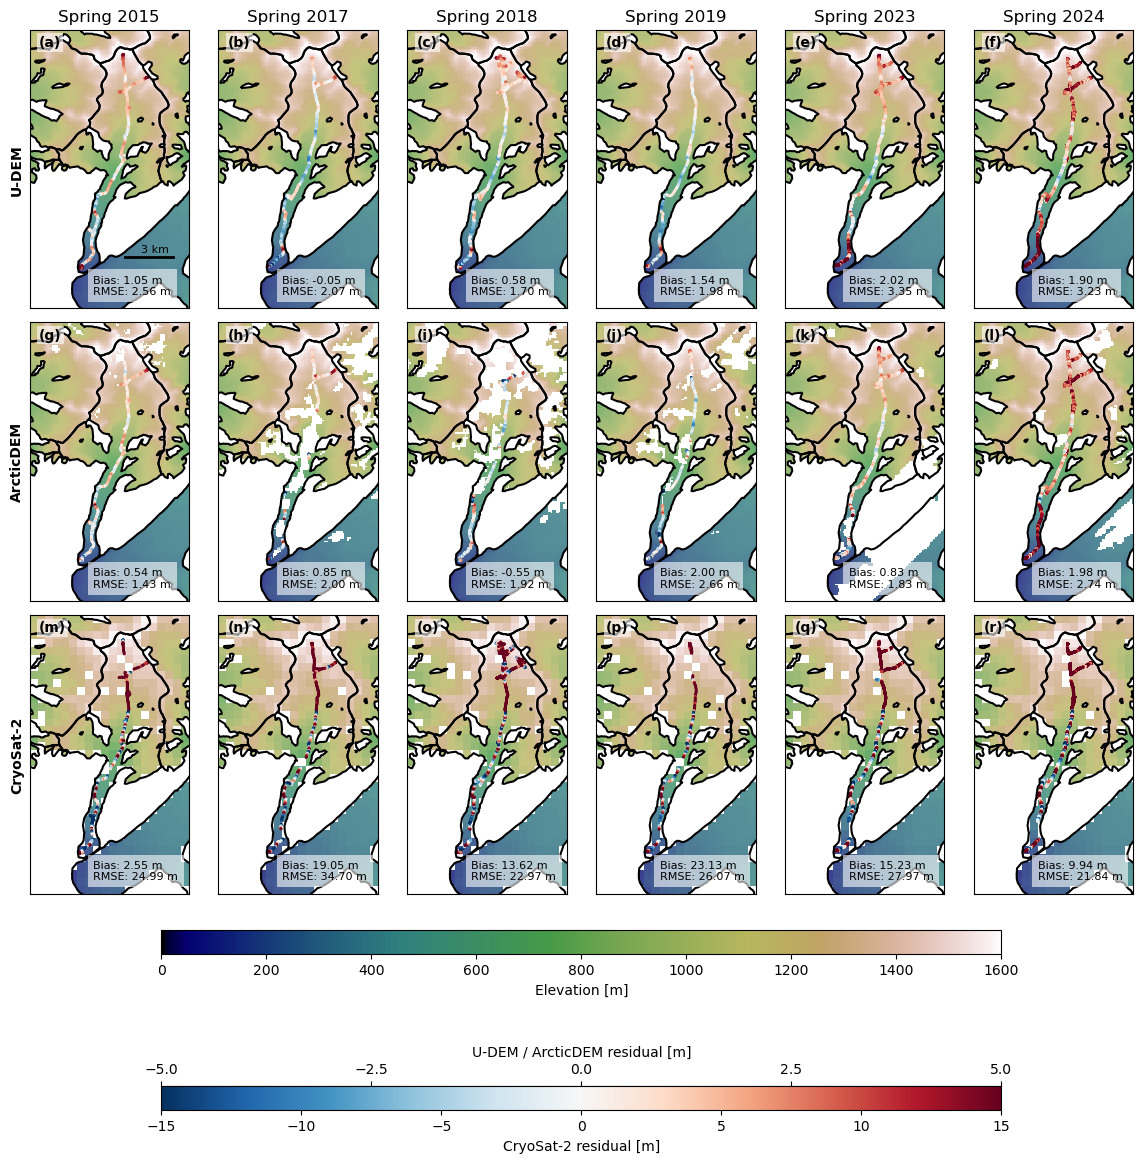

In [38]:
data_by_year = {
    2015: data_2015,
    2017: data_2017,
    2018: data_2018,
    2019: data_2019,
    2023: data_2023,
    2024: data_2024,
}

fig, ax = plot_spatial_difference_all_years(data_by_year)